# Dataset Exploration

This notebook inspects the panel datasets used by the SDF and RF training pipelines. It summarizes dataset availability, shapes, missingness, date alignment, and a few high-signal distribution checks for the character, macro, and generated RF datasets.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

UNK = -99.99

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists() and (candidate / "datasets").exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the repository root from the current notebook directory.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Repo root: {REPO_ROOT}")

Repo root: /Users/ricky/Developer/SDF_DL/SDF_DL


In [2]:
DATASETS = {
    "char": {
        "train": "datasets/char/Char_train.npz",
        "valid": "datasets/char/Char_valid.npz",
        "test": "datasets/char/Char_test.npz",
    },
    "macro": {
        "train": "datasets/macro/macro_train.npz",
        "valid": "datasets/macro/macro_valid.npz",
        "test": "datasets/macro/macro_test.npz",
    },
    "rf": {
        "train": "datasets/RF/RF_train_normalized_task_1.npz",
        "valid": "datasets/RF/RF_valid_normalized_task_1.npz",
        "test": "datasets/RF/RF_test_normalized_task_1.npz",
    },
}

In [3]:
def parse_dates(values):
    array = np.asarray(values)
    if np.issubdtype(array.dtype, np.integer):
        return pd.to_datetime(array.astype(str), format="%Y%m%d", errors="coerce")

    text = array.astype(str)
    if np.all(np.char.find(text, "/") >= 0):
        parsed = pd.to_datetime(text, format="%m/%d/%y", errors="coerce")
        parsed = pd.Series(parsed)
        parsed.loc[parsed.dt.year > pd.Timestamp.now().year] -= pd.DateOffset(years=100)
        return pd.DatetimeIndex(parsed)

    return pd.to_datetime(text, errors="coerce")


def inventory_table(dataset_map):
    rows = []
    for group, splits in dataset_map.items():
        for split, relative_path in splits.items():
            path = REPO_ROOT / relative_path
            rows.append(
                {
                    "group": group,
                    "split": split,
                    "path": relative_path,
                    "exists": path.exists(),
                    "size_mb": round(path.stat().st_size / 1024**2, 2) if path.exists() else np.nan,
                }
            )
    return pd.DataFrame(rows)


def load_available_npz(dataset_map):
    loaded = {}
    for group, splits in dataset_map.items():
        loaded[group] = {}
        for split, relative_path in splits.items():
            path = REPO_ROOT / relative_path
            if path.exists():
                loaded[group][split] = np.load(path, allow_pickle=False)
    return loaded


def summarize_panel(npz_obj, group, split):
    data = npz_obj["data"]
    returns = data[:, :, 0]
    mask = returns != UNK
    return {
        "group": group,
        "split": split,
        "months": data.shape[0],
        "max_firms": data.shape[1],
        "columns": data.shape[2],
        "char_features": data.shape[2] - 1,
        "valid_returns": int(mask.sum()),
        "missing_return_share": 1 - float(mask.mean()),
        "avg_firms_per_month": float(mask.sum(axis=1).mean()),
        "min_firms_per_month": int(mask.sum(axis=1).min()),
        "max_firms_per_month": int(mask.sum(axis=1).max()),
        "first_date": parse_dates(npz_obj["date"])[0],
        "last_date": parse_dates(npz_obj["date"])[-1],
        "has_permno": "permno" in npz_obj.files,
    }


def summarize_macro(npz_obj, split):
    data = npz_obj["data"]
    return {
        "split": split,
        "months": data.shape[0],
        "macro_features": data.shape[1],
        "mean_abs": float(np.abs(data).mean()),
        "std_mean": float(data.std(axis=0).mean()),
        "first_date": parse_dates(npz_obj["date"])[0],
        "last_date": parse_dates(npz_obj["date"])[-1],
    }


def sampled_valid_returns(npz_obj, max_points=200_000, seed=7):
    returns = npz_obj["data"][:, :, 0]
    valid = returns[returns != UNK]
    if valid.size <= max_points:
        return valid
    rng = np.random.default_rng(seed)
    return rng.choice(valid, size=max_points, replace=False)


def feature_missing_share(npz_obj):
    features = npz_obj["data"][:, :, 1:]
    variables = npz_obj["variable"][1:]
    missing = 1 - (features != UNK).mean(axis=(0, 1))
    return pd.Series(missing, index=variables).sort_values(ascending=False)


def return_summary(npz_obj, group, split):
    valid = npz_obj["data"][:, :, 0]
    valid = valid[valid != UNK]
    return {
        "group": group,
        "split": split,
        "mean": float(valid.mean()),
        "std": float(valid.std()),
        "p01": float(np.quantile(valid, 0.01)),
        "p50": float(np.quantile(valid, 0.50)),
        "p99": float(np.quantile(valid, 0.99)),
    }

## Inventory

In [4]:
inventory = inventory_table(DATASETS)
display(inventory)

missing = inventory.loc[~inventory["exists"], "path"].tolist()
if missing:
    print("Missing datasets:")
    for path in missing:
        print(f"  - {path}")
else:
    print("All expected dataset files are present.")

,group,split,path,exists,size_mb
0,char,train,datasets/char/Char_train.npz,True,317.2200
1,char,valid,datasets/char/Char_valid.npz,True,72.0100
2,char,test,datasets/char/Char_test.npz,True,768.1900
3,macro,train,datasets/macro/macro_train.npz,True,0.3400
4,macro,valid,datasets/macro/macro_valid.npz,True,0.0900
5,macro,test,datasets/macro/macro_test.npz,True,0.4300
6,rf,train,datasets/RF/RF_train_normalized_task_1.npz,True,317.2200
7,rf,valid,datasets/RF/RF_valid_normalized_task_1.npz,True,72.0100
8,rf,test,datasets/RF/RF_test_normalized_task_1.npz,True,768.1900


All expected dataset files are present.


In [5]:
datasets = load_available_npz(DATASETS)

panel_rows = []
for group in ("char", "rf"):
    for split, npz_obj in datasets.get(group, {}).items():
        panel_rows.append(summarize_panel(npz_obj, group, split))

macro_rows = []
for split, npz_obj in datasets.get("macro", {}).items():
    macro_rows.append(summarize_macro(npz_obj, split))

panel_summary = pd.DataFrame(panel_rows).set_index(["group", "split"]).sort_index()
macro_summary = pd.DataFrame(macro_rows).set_index("split").sort_index()

display(panel_summary)
display(macro_summary)

months  max_firms  columns  char_features  valid_returns  \
group split                                                             
char  test      300       7141       47             46         750275   
      train     240       3686       47             46         336113   
      valid      60       3347       47             46         132167   
rf    test      300       7141       47             46         750275   
      train     240       3686       47             46         336113   
      valid      60       3347       47             46         132167   

             missing_return_share  avg_firms_per_month  min_firms_per_month  \
group split                                                                   
char  test                 0.6498           2,500.9167                 1933   
      train                0.6201           1,400.4708                  430   
      valid                0.3419           2,202.7833                 2086   
rf    test                 0.6498           2,500.9167                 1933   
      train                0.6201           1,400.4708                  430   
      valid                0.3419           2,202.7833                 2086   

             max_firms_per_month first_date  last_date  has_permno  
group split                                                         
char  test                  2826 1992-01-31 2016-12-30       False  
      train                 2177 1967-01-31 1986-12-31       False  
      valid                 2397 1987-01-30 1991-12-31       False  
rf    test                  2826 1992-01-31 2016-12-30       False  
      train                 2177 1967-01-31 1986-12-31       False  
      valid                 2397 1987-01-30 1991-12-31       False

,months,macro_features,mean_abs,std_mean,first_date,last_date
split,,,,,,
test,300,178,1.9437,1.3832,1992-01-01,2016-12-01
train,240,178,1.4612,0.7887,1967-01-01,1986-12-01
valid,60,178,1.6283,0.8728,1987-01-01,1991-12-01


## Schema Checks

In [6]:
char_train = datasets["char"]["train"]
char_valid = datasets["char"]["valid"]
char_test = datasets["char"]["test"]

char_variables_match = np.array_equal(char_train["variable"], char_valid["variable"]) and np.array_equal(char_train["variable"], char_test["variable"])
print(f"Character variable lists aligned across splits: {char_variables_match}")
print("First 12 character columns:")
print(char_train["variable"][:12].tolist())

macro_train = datasets["macro"]["train"]
macro_valid = datasets["macro"]["valid"]
macro_test = datasets["macro"]["test"]

macro_variables_match = np.array_equal(macro_train["variable"], macro_valid["variable"]) and np.array_equal(macro_train["variable"], macro_test["variable"])
print(f"Macro variable lists aligned across splits: {macro_variables_match}")
print("First 12 macro columns:")
print(macro_train["variable"][:12].tolist())

date_alignment = pd.DataFrame(
    {
        "char_start": [parse_dates(char_train["date"])[0], parse_dates(char_valid["date"])[0], parse_dates(char_test["date"])[0]],
        "char_end": [parse_dates(char_train["date"])[-1], parse_dates(char_valid["date"])[-1], parse_dates(char_test["date"])[-1]],
        "macro_start": [parse_dates(macro_train["date"])[0], parse_dates(macro_valid["date"])[0], parse_dates(macro_test["date"])[0]],
        "macro_end": [parse_dates(macro_train["date"])[-1], parse_dates(macro_valid["date"])[-1], parse_dates(macro_test["date"])[-1]],
    },
    index=["train", "valid", "test"],
)
display(date_alignment)

Character variable lists aligned across splits: True
First 12 character columns:
['ret', 'A2ME', 'AC', 'AT', 'ATO', 'BEME', 'Beta', 'C', 'CF', 'CF2P', 'CTO', 'D2A']
Macro variable lists aligned across splits: True
First 12 macro columns:
['RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD', 'IPDCONGD', 'IPNCONGD', 'IPBUSEQ']


,char_start,char_end,macro_start,macro_end
train,1967-01-31,1986-12-31,1967-01-01,1986-12-01
valid,1987-01-30,1991-12-31,1987-01-01,1991-12-01
test,1992-01-31,2016-12-30,1992-01-01,2016-12-01


## Character Panel Diagnostics

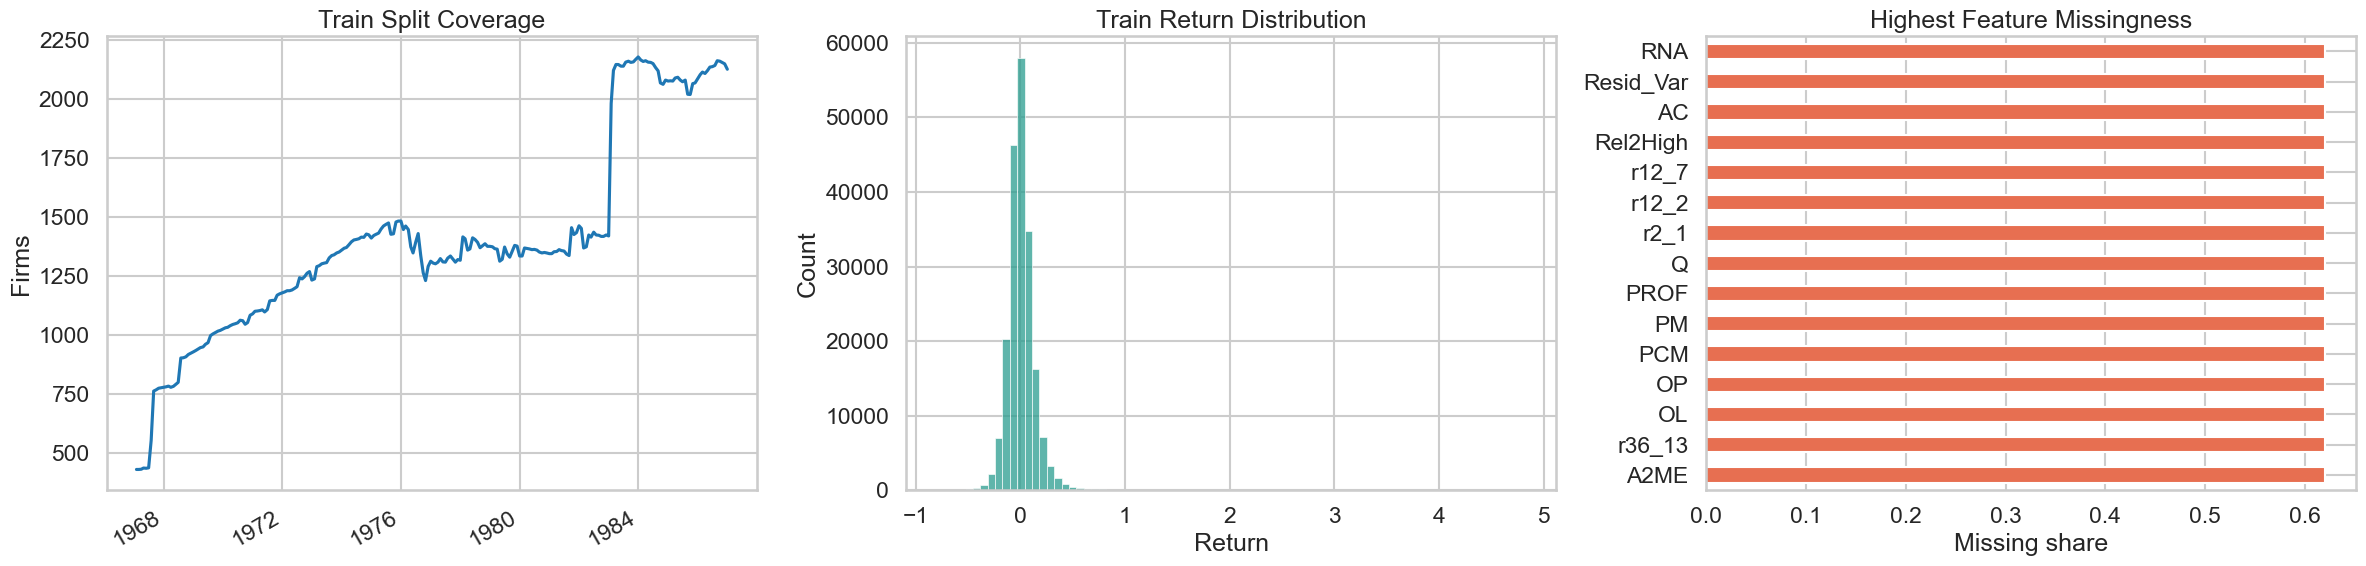

In [7]:
dates = parse_dates(char_train["date"])
returns = char_train["data"][:, :, 0]
mask = returns != UNK
coverage = pd.Series(mask.sum(axis=1), index=dates, name="firms_with_valid_returns")
return_sample = sampled_valid_returns(char_train)
missing_by_feature = feature_missing_share(char_train)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

coverage.plot(ax=axes[0], color="#1f77b4")
axes[0].set_title("Train Split Coverage")
axes[0].set_xlabel("")
axes[0].set_ylabel("Firms")

sns.histplot(return_sample, bins=80, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Train Return Distribution")
axes[1].set_xlabel("Return")

missing_by_feature.head(15).sort_values().plot.barh(ax=axes[2], color="#e76f51")
axes[2].set_title("Highest Feature Missingness")
axes[2].set_xlabel("Missing share")

plt.tight_layout()
plt.show()

In [8]:
coverage.describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
firms_with_valid_returns,240.0000,"1,400.4708",418.6905,430.0000,"1,181.0000","1,358.0000","1,446.0000","2,177.0000"


## Macro Diagnostics

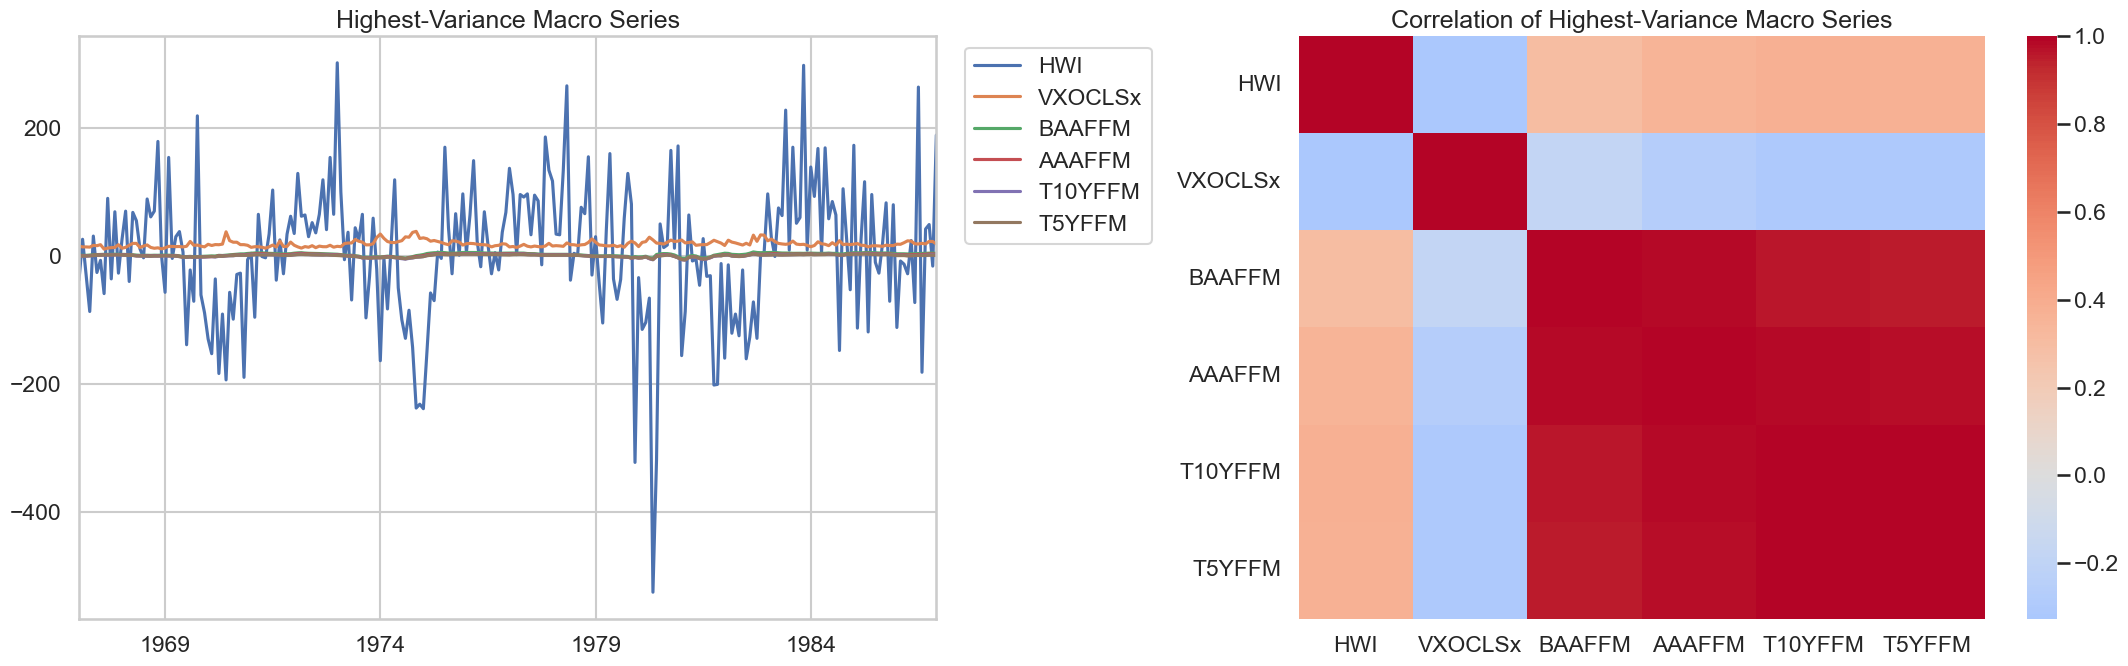

,count,mean,std,min,25%,50%,75%,max
HWI,240.0000,5.5167,107.4552,-526.0000,-43.0000,6.0000,65.2500,302.0000
VXOCLSx,240.0000,18.6801,4.7555,10.5770,15.3199,17.6167,21.0633,38.3682
BAAFFM,240.0000,2.2602,2.3426,-4.0500,0.7125,2.8000,4.2475,6.2000
AAAFFM,240.0000,1.0290,2.2296,-6.2700,-0.4050,1.6950,2.7875,3.9800
T10YFFM,240.0000,0.3606,2.0813,-6.5100,-0.8600,1.0100,2.0125,3.2800
T5YFFM,240.0000,0.2691,1.8633,-6.3100,-0.8250,0.8300,1.6600,2.9400


In [9]:
macro_dates = parse_dates(macro_train["date"])
macro_df = pd.DataFrame(macro_train["data"], index=macro_dates, columns=macro_train["variable"])
top_macro = macro_df.var().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

macro_df[top_macro].plot(ax=axes[0])
axes[0].set_title("Highest-Variance Macro Series")
axes[0].set_xlabel("")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

sns.heatmap(macro_df[top_macro].corr(), cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Correlation of Highest-Variance Macro Series")

plt.tight_layout()
plt.show()

macro_df[top_macro].describe().T

## RF Comparison

mean    std     p01     p50    p99
group split                                      
char  test   0.0115 0.1729 -0.3716  0.0010 0.5419
      train  0.0073 0.1288 -0.2732 -0.0046 0.4066
      valid  0.0068 0.1660 -0.3737 -0.0047 0.5052
rf    test  -0.0005 0.1536 -0.3966 -0.0001 0.4198
      train  0.0132 0.1318 -0.2616 -0.0038 0.4682
      valid  0.0055 0.1073 -0.2907 -0.0002 0.3557

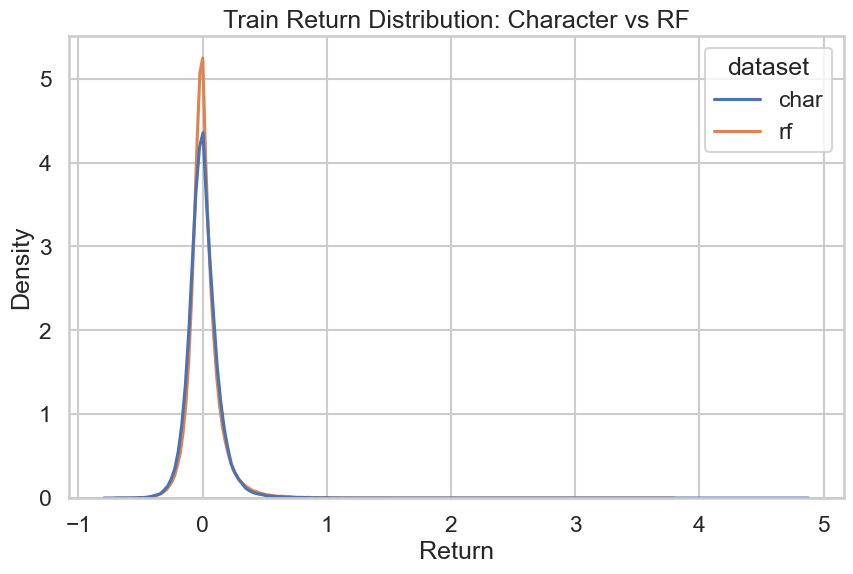

In [10]:
if datasets.get("rf"):
    comparison_rows = []
    for split, npz_obj in datasets["char"].items():
        comparison_rows.append(return_summary(npz_obj, "char", split))
    for split, npz_obj in datasets["rf"].items():
        comparison_rows.append(return_summary(npz_obj, "rf", split))

    comparison = pd.DataFrame(comparison_rows).set_index(["group", "split"]).sort_index()
    display(comparison)

    char_rf_train = pd.DataFrame(
        {
            "value": np.concatenate([
                sampled_valid_returns(datasets["char"]["train"], max_points=120_000),
                sampled_valid_returns(datasets["rf"]["train"], max_points=120_000),
            ]),
            "dataset": ["char"] * min(120_000, (datasets["char"]["train"]["data"][:, :, 0] != UNK).sum())
            + ["rf"] * min(120_000, (datasets["rf"]["train"]["data"][:, :, 0] != UNK).sum()),
        }
    )

    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=char_rf_train, x="value", hue="dataset", common_norm=False)
    plt.title("Train Return Distribution: Character vs RF")
    plt.xlabel("Return")
    plt.show()
else:
    print("RF datasets are not present yet. Run create_RF_data.py and rerun this section.")